# 1) Chargement des données

In [1]:
# Chargement des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import du fichier
df = pd.read_csv("billets.csv",sep=";")

df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
# Dimensions et structure
print(f"Nombre de billets : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")

df.info()

Nombre de billets : 1500
Nombre de variables : 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


### Structure du jeu de données

Le jeu de données contient 1 500 billets décrits par six caractéristiques géométriques ainsi que la variable cible `is_genuine`, indiquant si le billet est authentique ou non.

In [4]:
# Contrôle des doublons
df.duplicated().sum()

np.int64(0)

Aucun doublon exact n'est présent dans le jeu de données.

In [5]:
# Valeurs manquantes
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [6]:
# Pourcentage de valeurs manquantes
(df.isna().sum() / len(df) * 100).round(2)

is_genuine      0.00
diagonal        0.00
height_left     0.00
height_right    0.00
margin_low      2.47
margin_up       0.00
length          0.00
dtype: float64

### Valeurs manquantes

La variable `margin_low` contient 37 valeurs manquantes, soit environ 2,47 % des observations. Les autres variables sont complètes.

Le traitement de ces valeurs sera déterminé après l'analyse exploratoire de la variable et de sa relation avec la variable cible.

In [7]:
# Vérification de la cible
df["is_genuine"].value_counts()

is_genuine
True     1000
False     500
Name: count, dtype: int64

In [8]:
# Pourcentage de true et false
df["is_genuine"].value_counts(normalize=True).mul(100).round(2)

is_genuine
True     66.67
False    33.33
Name: proportion, dtype: float64

# 2) Analyse exploratoire (EDA)


### 2.1 Statistiques descriptives

Une première analyse statistique permet d'étudier la distribution des différentes caractéristiques géométriques des billets : tendance centrale, dispersion, quartiles et valeurs extrêmes.

In [9]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


**Premières observations :**

Les six caractéristiques géométriques présentent des ordres de grandeur et des dispersions différents. Aucune valeur manifestement incohérente n'apparaît à ce stade.

La variable `margin_low` ne contient que 1 463 observations, ce qui confirme la présence des 37 valeurs manquantes identifiées précédemment.

L'analyse des distributions et la comparaison entre billets authentiques et faux billets permettront d'identifier plus précisément les variables susceptibles de contribuer à la classification.

In [10]:
# Liste des six caractéristiques géométriques utilisées
# pour décrire les billets.
# La variable cible "is_genuine" n'est pas incluse car elle
# correspond à la classe du billet et non à une mesure géométrique.

variables = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length"
]

### 2.2 Distribution des caractéristiques géométriques

L'étude des distributions permet d'observer la forme, la dispersion et les éventuelles valeurs extrêmes des différentes caractéristiques géométriques.

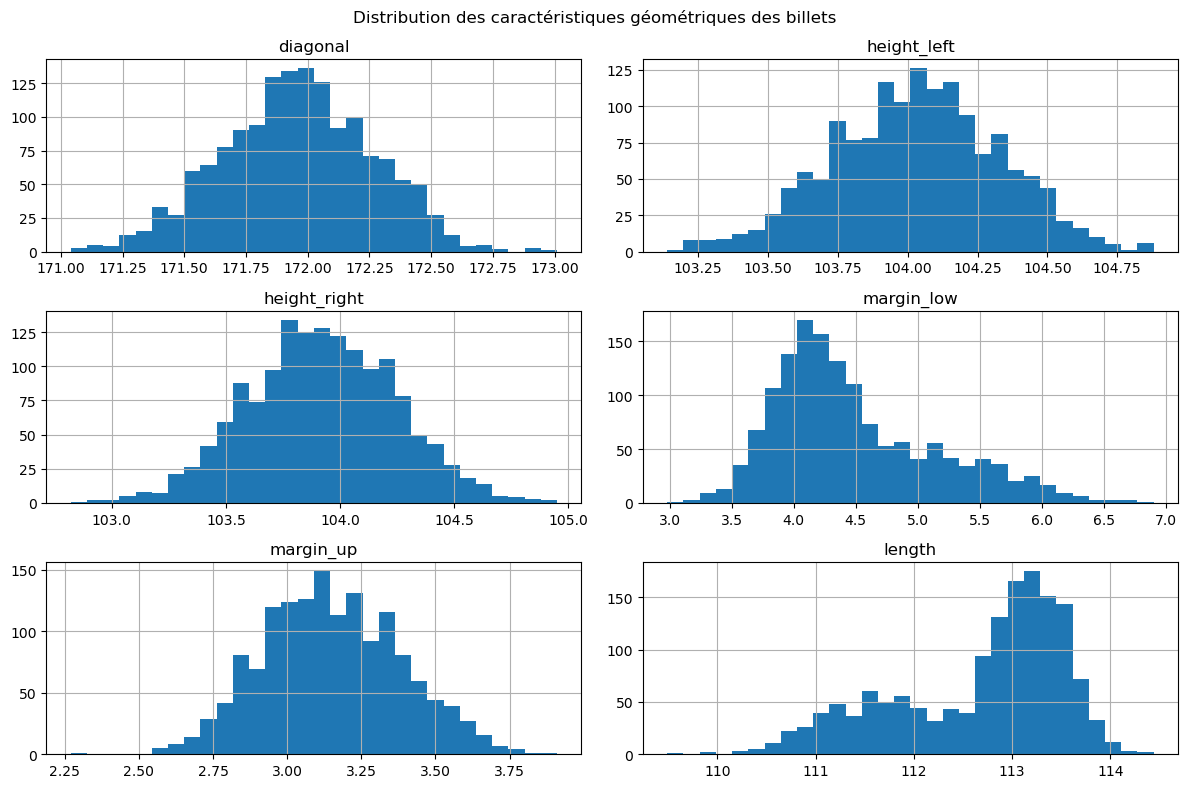

In [11]:
# Affichage d'un histogramme pour chacune des six
# caractéristiques géométriques.
#
# Les histogrammes permettent d'observer :
# - la forme des distributions ;
# - leur dispersion ;
# - la présence éventuelle de plusieurs groupes ;
# - d'éventuelles valeurs extrêmes.

df[variables].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distribution des caractéristiques géométriques des billets")

# Ajustement automatique de l'espacement entre les graphiques
plt.tight_layout()

plt.show()

**Analyse des distributions :**

Les variables `diagonal`, `height_left`, `height_right` et `margin_up` présentent des distributions relativement concentrées.

Les distributions de `margin_low` et surtout de `length` semblent davantage hétérogènes. Pour `length`, deux zones de concentration apparaissent visuellement, ce qui peut suggérer l'existence de différences entre les deux classes de billets.

La comparaison des distributions selon la variable cible `is_genuine` permettra de vérifier cette hypothèse.

### 2.3 Comparaison des caractéristiques selon l'authenticité du billet

Les distributions des différentes caractéristiques sont comparées entre les billets authentiques et les faux billets afin d'identifier les variables susceptibles de contribuer à leur différenciation.

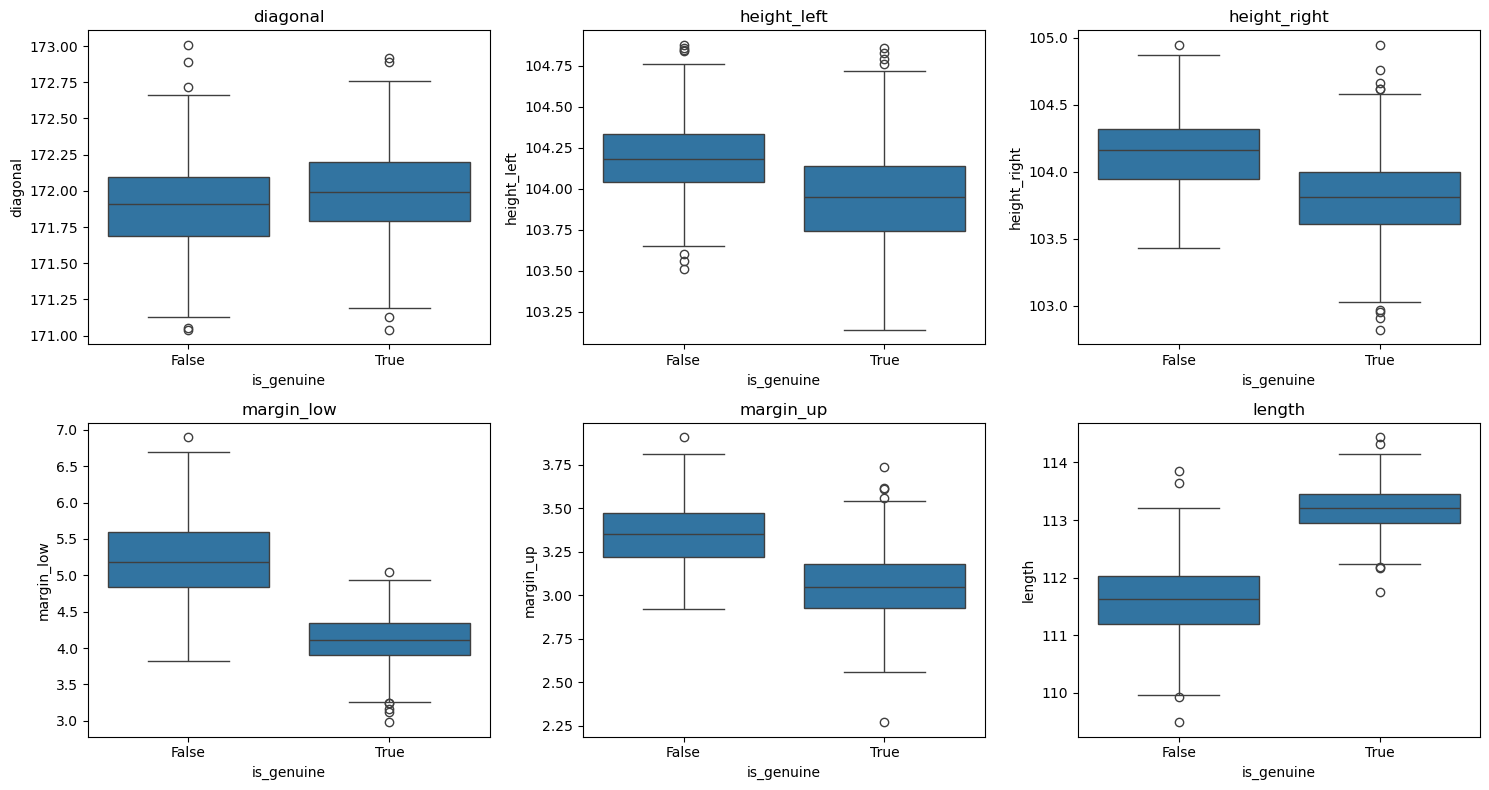

In [12]:
# Création d'une figure composée de 6 graphiques :
# 2 lignes × 3 colonnes.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))


# Pour chaque caractéristique géométrique,
# création d'un boxplot comparant les vrais et faux billets.
for variable, ax in zip(variables, axes.flatten()):

    sns.boxplot(
        data=df,
        x="is_genuine",   # False = faux billet / True = vrai billet
        y=variable,       # Caractéristique étudiée
        ax=ax
    )

    ax.set_title(variable)


# Ajustement de l'espacement entre les graphiques
plt.tight_layout()

plt.show()

### 2.4 Comparaison des moyennes selon l'authenticité

Les moyennes des différentes caractéristiques géométriques sont calculées séparément pour les billets authentiques et les faux billets afin de compléter l'analyse graphique.

In [13]:
# Calcul de la moyenne de chaque caractéristique géométrique
# selon la classe du billet.
#
# False = faux billet
# True  = billet authentique

moyennes_par_classe = (
    df.groupby("is_genuine")[variables]
      .mean()
      .round(2)
)

moyennes_par_classe

,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,,,,,,
False,171.90,104.19,104.14,5.22,3.35,111.63
True,171.99,103.95,103.81,4.12,3.05,113.20


**Comparaison entre billets authentiques et faux billets :**

La comparaison des distributions met en évidence des différences entre les deux classes.

Les variables `length` et `margin_low` présentent les séparations les plus marquées entre billets authentiques et faux billets. Les billets authentiques ont en moyenne une longueur plus élevée, tandis que les faux billets présentent une marge inférieure (`margin_low`) plus importante.

Les variables `margin_up`, `height_right` et `height_left` présentent également des différences entre les deux classes, mais avec un chevauchement plus important de leurs distributions.

À l'inverse, la variable `diagonal` présente des distributions très similaires entre les deux classes et semble donc, prise isolément, moins discriminante.

Ces observations suggèrent que certaines caractéristiques géométriques pourraient contribuer davantage que d'autres à la classification des billets. Cette hypothèse sera approfondie par l'étude des corrélations puis par la modélisation.

### 2.5 Analyse des corrélations

Une matrice de corrélation est utilisée afin d'étudier les relations linéaires entre les différentes caractéristiques géométriques ainsi que leur relation avec la variable cible.

Pour cette analyse, la variable booléenne `is_genuine` est temporairement convertie en variable numérique (`False = 0`, `True = 1`).

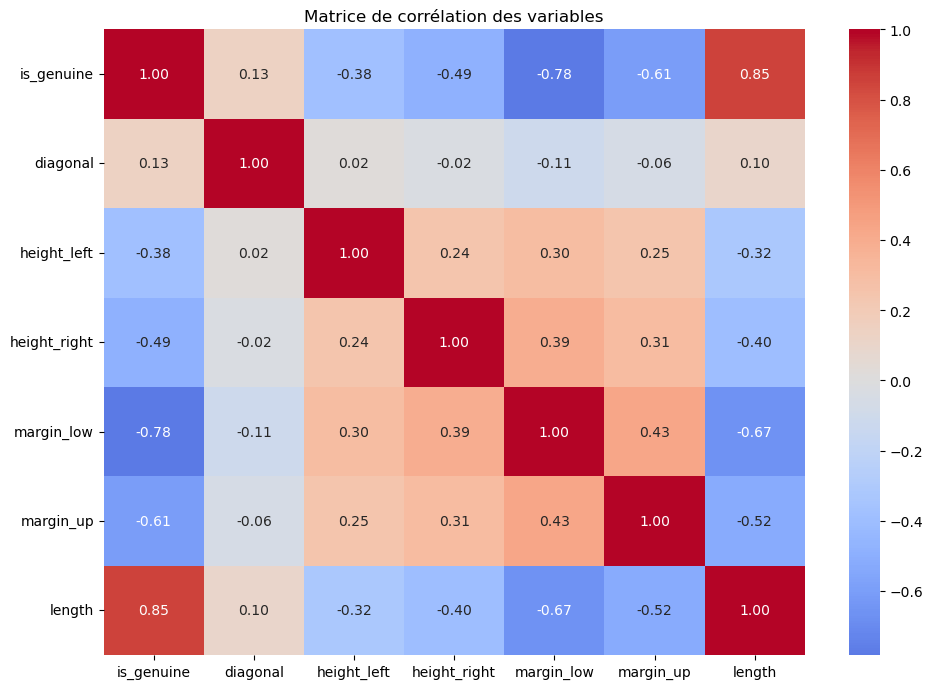

In [14]:
# Création d'une copie du jeu de données pour l'analyse des corrélations.
# Cela permet de conserver le DataFrame original "df" inchangé.
df_corr = df.copy()


# Conversion de la variable cible booléenne en valeurs numériques :
# False (faux billet) = 0
# True  (billet authentique) = 1
#
# Cette conversion permet d'inclure explicitement la cible
# dans la matrice de corrélation.
df_corr["is_genuine"] = df_corr["is_genuine"].astype(int)


# Calcul de la matrice de corrélation de Pearson.
# Une valeur proche de :
# +1 indique une relation linéaire positive forte ;
# -1 indique une relation linéaire négative forte ;
#  0 indique peu ou pas de relation linéaire.
correlation_matrix = df_corr.corr()


# Affichage de la matrice sous forme de heatmap
# afin de faciliter l'identification des relations entre variables.
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,        # Affiche la valeur de chaque corrélation
    fmt=".2f",         # Limite l'affichage à deux décimales
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

**Analyse des corrélations :**

La matrice de corrélation confirme les tendances observées lors de l'analyse des distributions par classe.

La variable `length` présente une relation positive importante avec `is_genuine` : les billets authentiques ont généralement une longueur plus élevée.

À l'inverse, `margin_low` présente une relation négative importante avec la cible : une marge inférieure plus élevée est davantage observée parmi les faux billets.

Les variables `margin_up`, `height_right` et `height_left` présentent également des relations avec l'authenticité, tandis que `diagonal` semble moins fortement liée à la cible.

Ces corrélations décrivent des relations linéaires et ne suffisent cependant pas, à elles seules, à déterminer l'importance prédictive des variables. Celle-ci sera évaluée lors de la modélisation.

### 2.6 Analyse des valeurs manquantes de `margin_low`

La variable `margin_low` contient 37 valeurs manquantes. Avant de choisir une méthode de traitement, il est utile d'étudier la répartition de ces observations selon la classe du billet.

In [15]:
# Sélection des observations pour lesquelles
# la variable "margin_low" est manquante.
missing_margin_low = df[df["margin_low"].isna()]


# Comptage des valeurs manquantes selon la classe du billet.
#
# Cela permet de vérifier si les valeurs manquantes concernent
# uniquement une classe ou si elles sont réparties entre
# billets authentiques et faux billets.
missing_margin_low["is_genuine"].value_counts()

is_genuine
True     29
False     8
Name: count, dtype: int64

In [16]:
# Calcul du pourcentage de valeurs manquantes de "margin_low"
# au sein de chaque classe.
#
# On compare ici le nombre de valeurs manquantes au nombre total
# de billets de chaque classe.

(
    df.groupby("is_genuine")["margin_low"]
      .apply(lambda x: x.isna().mean() * 100)
      .round(2)
)

is_genuine
False    1.6
True     2.9
Name: margin_low, dtype: float64

**Traitement envisagé des valeurs manquantes :**

Les 37 valeurs manquantes de `margin_low` représentent environ 2,47 % du jeu de données. Elles concernent 29 billets authentiques et 8 faux billets, soit respectivement 2,9 % et 1,6 % des observations de chaque classe.

Ces observations seront conservées afin de ne pas perdre d'information, d'autant plus que `margin_low` semble être une variable discriminante.

Une imputation par la médiane sera utilisée lors du prétraitement. La médiane est privilégiée pour sa robustesse aux valeurs atypiques. Afin d'éviter toute fuite de données, la valeur d'imputation sera apprise uniquement sur les données d'entraînement puis appliquée aux données de test.

### 2.7 Analyse des valeurs atypiques

Les boxplots mettent en évidence certaines observations éloignées du reste des distributions.

La méthode de l'écart interquartile (IQR) est utilisée pour identifier ces valeurs atypiques. Leur détection ne signifie cependant pas qu'elles doivent automatiquement être supprimées : une valeur atypique peut correspondre à une observation réelle.

In [17]:
# Dictionnaire qui contiendra le nombre de valeurs
# considérées comme atypiques pour chaque variable.
outliers = {}


# Analyse de chacune des six caractéristiques géométriques.
for variable in variables:

    # Premier quartile : 25 % des valeurs sont inférieures à Q1.
    Q1 = df[variable].quantile(0.25)

    # Troisième quartile : 75 % des valeurs sont inférieures à Q3.
    Q3 = df[variable].quantile(0.75)

    # Écart interquartile.
    IQR = Q3 - Q1

    # Bornes classiquement utilisées pour identifier
    # les observations potentiellement atypiques.
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # Comptage des observations situées en dehors des bornes.
    outliers[variable] = (
        (df[variable] < borne_inf) |
        (df[variable] > borne_sup)
    ).sum()


# Transformation en Series pour obtenir
# un affichage plus lisible.
pd.Series(outliers, name="Nombre de valeurs atypiques")

diagonal         7
height_left      6
height_right    11
margin_low      24
margin_up        3
length           3
Name: Nombre de valeurs atypiques, dtype: int64

**Interprétation des valeurs atypiques :**

La méthode IQR identifie quelques observations atypiques pour chacune des caractéristiques, avec un nombre plus important pour `margin_low` (24 observations).

Ces valeurs restent néanmoins compatibles avec les plages de mesures observées dans le jeu de données et aucune incohérence manifeste n'a été identifiée.

Une valeur détectée comme atypique par la méthode IQR n'étant pas nécessairement une donnée erronée, ces observations sont conservées pour la modélisation.

## 3 Prétraitement


## 3.1 Séparation des variables explicatives et de la cible

In [18]:
# Sélection des six caractéristiques géométriques utilisées
# comme variables explicatives (features).
#
# La variable "is_genuine" est volontairement exclue de X,
# car il s'agit de la variable que le modèle devra prédire.

X = df[
    [
        "diagonal",
        "height_left",
        "height_right",
        "margin_low",
        "margin_up",
        "length"
    ]
]


# Sélection de la variable cible.
#
# False = faux billet
# True  = billet authentique

y = df["is_genuine"]

In [19]:
# Vérification des dimensions de X et y.
# X doit contenir 1 500 observations et 6 variables.
# y doit contenir 1 500 étiquettes.

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1500, 6)
Dimensions de y : (1500,)


## 3.2 Séparation des données en ensembles d'entraînement et de test

In [20]:
from sklearn.model_selection import train_test_split


# Séparation du jeu de données :
# - 80 % pour entraîner les modèles ;
# - 20 % pour évaluer leurs performances sur des données non vues.
#
# random_state=42 permet de reproduire exactement la même séparation
# à chaque exécution du notebook.
#
# stratify=y permet de conserver approximativement la même proportion
# de vrais et faux billets dans les ensembles d'entraînement et de test.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Vérification des dimensions obtenues.
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1200, 6)
X_test  : (300, 6)
y_train : (1200,)
y_test  : (300,)


## 3.3 Traitement des valeurs manquantes

In [21]:
from sklearn.impute import SimpleImputer


# Création de l'imputeur.
# Les valeurs manquantes seront remplacées par la médiane
# calculée sur les données d'entraînement.

imputer = SimpleImputer(strategy="median")


# IMPORTANT :
# fit_transform() sur X_train :
# l'imputeur CALCULE la médiane à partir du train,
# puis remplace les valeurs manquantes.

X_train_imputed = imputer.fit_transform(X_train)


# transform() uniquement sur X_test :
# on réutilise la médiane calculée sur X_train.
#
# On ne fait PAS fit_transform(X_test), car cela ferait apprendre
# le preprocessing à partir des données de test.

X_test_imputed = imputer.transform(X_test)

In [22]:
# Vérification qu'aucune valeur manquante ne subsiste
# après l'imputation.

print("NaN dans X_train :", np.isnan(X_train_imputed).sum())
print("NaN dans X_test :", np.isnan(X_test_imputed).sum())

NaN dans X_train : 0
NaN dans X_test : 0


## 3.4 Standardisation des variables

In [23]:
# Standardisation

from sklearn.preprocessing import StandardScaler


# Création du StandardScaler.
# Il permettra de mettre les différentes variables
# sur une échelle comparable.
scaler = StandardScaler()


# Apprentissage des paramètres de standardisation sur X_train :
# - moyenne de chaque variable ;
# - écart-type de chaque variable.
#
# Puis transformation des données d'entraînement.
X_train_scaled = scaler.fit_transform(X_train_imputed)


# Transformation de X_test avec EXACTEMENT les moyennes
# et écarts-types appris sur X_train.
#
# On n'utilise pas fit_transform() sur X_test afin d'éviter
# toute fuite d'information provenant des données de test.
X_test_scaled = scaler.transform(X_test_imputed)

In [24]:
# Vérification de la standardisation.
#
# Après StandardScaler, les variables de X_train doivent avoir
# une moyenne très proche de 0 et un écart-type proche de 1.

print(
    "Moyennes après standardisation :",
    np.round(X_train_scaled.mean(axis=0), 2)
)

print(
    "Écarts-types après standardisation :",
    np.round(X_train_scaled.std(axis=0), 2)
)

Moyennes après standardisation : [ 0. -0.  0.  0.  0. -0.]
Écarts-types après standardisation : [1. 1. 1. 1. 1. 1.]


## 4 Modélisation


## 4.1 Régression logistique

In [25]:
from sklearn.linear_model import LogisticRegression


# Initialisation du modèle de régression logistique.
#
# max_iter=1000 fixe le nombre maximal d'itérations utilisées
# par l'algorithme pour trouver les coefficients du modèle.
#
# On augmente ici cette valeur par rapport à la valeur par défaut
# afin de laisser suffisamment d'itérations au modèle pour converger.
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Entraînement du modèle.
#
# Le modèle apprend à partir :
# - des six caractéristiques géométriques standardisées ;
# - de la véritable classe de chacun des billets du train.
log_reg.fit(X_train_scaled, y_train)


# Prédiction de la classe des billets du jeu de test.
#
# Le modèle applique ici ce qu'il a appris à des billets
# qu'il n'a jamais vus pendant son entraînement.
y_pred_log = log_reg.predict(X_test_scaled)


# Affichage des dix premières prédictions.
y_pred_log[:10]

array([ True, False, False,  True,  True,  True,  True,  True,  True,
        True])

In [26]:
# Calcul des probabilités estimées pour chaque classe.
#
# Colonne 0 : probabilité que le billet soit False = faux
# Colonne 1 : probabilité que le billet soit True = authentique
probabilites_log = log_reg.predict_proba(X_test_scaled)


# Affichage des cinq premières probabilités.
probabilites_log[:5]

array([[9.90621885e-04, 9.99009378e-01],
       [9.99975684e-01, 2.43160539e-05],
       [9.99974849e-01, 2.51506397e-05],
       [3.59895088e-01, 6.40104912e-01],
       [2.34191123e-03, 9.97658089e-01]])

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# Calcul des principales métriques du modèle.
#
# IMPORTANT :
# par défaut, sklearn considère True comme la classe positive.
# Ces métriques décrivent donc ici principalement la capacité
# du modèle à reconnaître les billets authentiques.

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)


print("Accuracy :", round(accuracy_log, 3))
print("Precision :", round(precision_log, 3))
print("Recall :", round(recall_log, 3))
print("F1-score :", round(f1_log, 3))

Accuracy : 0.99
Precision : 0.99
Recall : 0.995
F1-score : 0.993


In [28]:
# Calcul du recall pour les faux billets.
#
# pos_label=False indique que nous considérons ici les faux billets
# comme la classe d'intérêt.
#
# Le recall répond à la question :
# "Parmi tous les faux billets réellement présents,
# quelle proportion le modèle a-t-il détectée ?"

recall_faux_log = recall_score(
    y_test,
    y_pred_log,
    pos_label=False
)


# Calcul de la précision pour les faux billets.
#
# Elle répond à la question :
# "Parmi tous les billets prédits comme faux,
# quelle proportion est réellement fausse ?"

precision_faux_log = precision_score(
    y_test,
    y_pred_log,
    pos_label=False
)


print("Recall des faux billets :", round(recall_faux_log, 3))
print("Précision des faux billets :", round(precision_faux_log, 3))

Recall des faux billets : 0.98
Précision des faux billets : 0.99


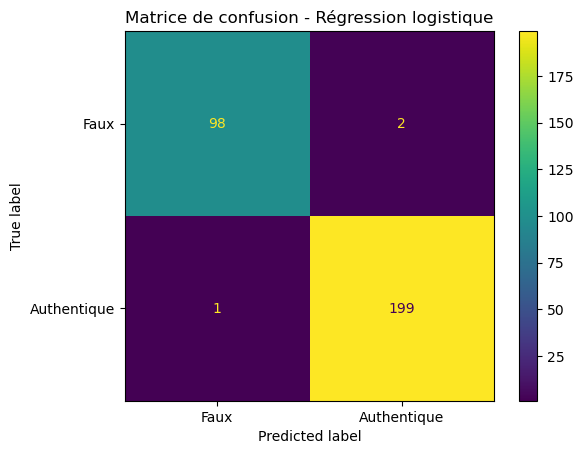

In [29]:
# Affichage de la matrice de confusion.
#
# Les classes sont explicitement ordonnées :
# False = faux billet
# True  = billet authentique.
#
# La matrice permettra d'identifier précisément
# les erreurs réalisées par le modèle.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    labels=[False, True],
    display_labels=["Faux", "Authentique"]
)

plt.title("Matrice de confusion - Régression logistique")
plt.show()

In [30]:
# Comparaison des performances sur les données d'entraînement
# et sur les données de test.
#
# Cette comparaison permet de vérifier si le modèle généralise
# correctement à de nouvelles observations et de détecter
# un éventuel surapprentissage (overfitting).

accuracy_train_log = log_reg.score(
    X_train_scaled,
    y_train
)

accuracy_test_log = log_reg.score(
    X_test_scaled,
    y_test
)

print("Accuracy train :", round(accuracy_train_log, 3))
print("Accuracy test :", round(accuracy_test_log, 3))

Accuracy train : 0.993
Accuracy test : 0.99


### Conclusion - Régression logistique

La régression logistique obtient de très bonnes performances, avec une accuracy de 99,3 % sur l'ensemble d'entraînement et de 99,0 % sur l'ensemble de test. La proximité de ces deux résultats ne met pas en évidence de surapprentissage important.

Sur les 300 billets du jeu de test, 297 sont correctement classés. Le modèle identifie correctement 98 % des faux billets. Deux faux billets sont néanmoins classés comme authentiques, ce qui constitue une erreur particulièrement importante dans le contexte métier.

Ces résultats serviront de référence pour comparer la régression logistique aux autres modèles étudiés.

### 4.2 K plus proches voisins (KNN)

Le KNN est un algorithme de classification supervisée qui attribue une classe à une nouvelle observation en fonction des classes de ses voisins les plus proches.

Le nombre de voisins `K` constitue un hyperparamètre du modèle. Afin de ne pas choisir arbitrairement sa valeur, plusieurs valeurs de `K` sont comparées par validation croisée sur l'ensemble d'entraînement.

Les variables sont standardisées car le KNN repose sur le calcul de distances entre les observations. L'imputation et la standardisation sont intégrées dans un pipeline afin qu'elles soient apprises uniquement à partir des données d'entraînement de chaque étape de la validation croisée.

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Création d'un scorer correspondant à l'objectif métier.
#
# Dans notre variable cible :
# False = faux billet
# True  = billet authentique
#
# pos_label=False permet donc d'évaluer spécifiquement
# la capacité du modèle à détecter les faux billets.
recall_faux_scorer = make_scorer(
    recall_score,
    pos_label=False
)


# Création du pipeline KNN.
#
# Pour chaque entraînement réalisé pendant la validation croisée :
# 1. les valeurs manquantes sont imputées par la médiane ;
# 2. les variables sont standardisées ;
# 3. le modèle KNN est entraîné.
#
# Les paramètres du preprocessing sont ainsi appris uniquement
# à partir des données d'entraînement concernées.
pipeline_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])


# Définition des valeurs de K à comparer.
#
# K est un hyperparamètre : sa valeur n'est pas apprise
# automatiquement par le modèle.
#
# Plusieurs petites valeurs impaires sont testées afin de comparer
# différentes tailles de voisinage et de limiter les égalités
# de vote dans ce problème de classification binaire.
param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15]
}


# Recherche de la valeur de K par validation croisée à 5 plis.
#
# scoring utilise ici le recall des faux billets,
# conformément à l'objectif métier de détection des contrefaçons.
#
# Le jeu de test n'intervient pas dans cette recherche.
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring=recall_faux_scorer,
    cv=5
)


# IMPORTANT :
# On utilise X_train original.
#
# Il ne faut pas utiliser X_train_scaled ici car l'imputation
# et la standardisation sont désormais réalisées directement
# dans le pipeline pendant la validation croisée.
grid_knn.fit(
    X_train,
    y_train
)


print(
    "Meilleur K :",
    grid_knn.best_params_["knn__n_neighbors"]
)

print(
    "Recall faux moyen en validation croisée :",
    round(grid_knn.best_score_, 3)
)

Meilleur K : 5
Recall faux moyen en validation croisée : 0.98


In [32]:
# Récupération du meilleur pipeline trouvé par GridSearchCV.
#
# best_estimator_ contient directement :
# Imputer → StandardScaler → KNN avec le meilleur K sélectionné.
best_knn = grid_knn.best_estimator_


# Prédiction sur le jeu de test.
#
# X_test est utilisé ici pour la première fois dans cette procédure
# de sélection afin d'évaluer les performances du modèle retenu.
#
# Le pipeline applique automatiquement l'imputation,
# la standardisation puis le KNN.
y_pred_knn = best_knn.predict(X_test)


# Affichage des dix premières prédictions.
y_pred_knn[:10]

array([ True, False, False,  True,  True,  True,  True,  True,  True,
        True])

In [33]:
# Calcul des performances générales du KNN sélectionné.

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn
)

recall_knn = recall_score(
    y_test,
    y_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_pred_knn
)


# Calcul des métriques spécifiques aux faux billets.
#
# Elles sont particulièrement importantes dans notre contexte métier.

recall_faux_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label=False
)

precision_faux_knn = precision_score(
    y_test,
    y_pred_knn,
    pos_label=False
)


print("Accuracy :", round(accuracy_knn, 3))
print("Precision :", round(precision_knn, 3))
print("Recall :", round(recall_knn, 3))
print("F1-score :", round(f1_knn, 3))

print(
    "Recall des faux billets :",
    round(recall_faux_knn, 3)
)

print(
    "Précision des faux billets :",
    round(precision_faux_knn, 3)
)

Accuracy : 0.983
Precision : 0.985
Recall : 0.99
F1-score : 0.988
Recall des faux billets : 0.97
Précision des faux billets : 0.98


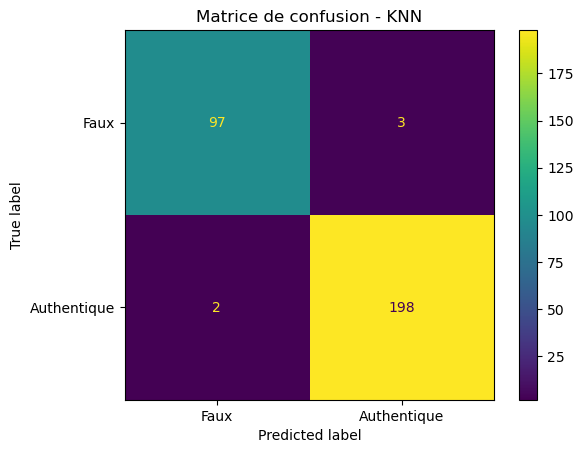

In [34]:
# Affichage de la matrice de confusion du KNN sélectionné.
#
# L'ordre des classes est imposé afin de faciliter
# l'interprétation :
# False = faux billet
# True  = billet authentique.
#
# Cette matrice permet notamment d'identifier les faux billets
# qui auraient été classés à tort comme authentiques.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    labels=[False, True],
    display_labels=["Faux", "Authentique"]
)

plt.title("Matrice de confusion - KNN")
plt.show()

In [35]:
# Comparaison des performances sur les ensembles
# d'entraînement et de test.
#
# Cette comparaison permet d'observer si les performances
# restent similaires sur des données non utilisées pour
# l'entraînement.

accuracy_train_knn = best_knn.score(
    X_train,
    y_train
)

accuracy_test_knn = best_knn.score(
    X_test,
    y_test
)


print(
    "Accuracy train :",
    round(accuracy_train_knn, 3)
)

print(
    "Accuracy test :",
    round(accuracy_test_knn, 3)
)

Accuracy train : 0.993
Accuracy test : 0.983


### Conclusion - KNN

Le nombre de voisins du KNN a été sélectionné par validation croisée sur l'ensemble d'entraînement. Parmi les valeurs testées, `K = 5` obtient le meilleur recall moyen des faux billets, égal à 98 % en validation croisée.

Sur l'ensemble de test, le modèle obtient une accuracy de 98,3 % et détecte correctement 97 % des faux billets. Trois faux billets sont classés à tort comme authentiques.

L'accuracy de 99,3 % sur l'ensemble d'entraînement contre 98,3 % sur l'ensemble de test ne met pas en évidence de surapprentissage important.

Ces performances seront comparées à celles des autres modèles avant la sélection du modèle final.

### 4.3 Random Forest

La Random Forest est un algorithme supervisé reposant sur un ensemble d'arbres de décision. Les prédictions des différents arbres sont agrégées afin de déterminer la classe finale.

Contrairement au KNN, la Random Forest ne repose pas sur le calcul de distances entre les observations. La standardisation des variables n'est donc pas nécessaire.

Un pipeline est néanmoins utilisé afin d'intégrer le traitement des valeurs manquantes avant l'entraînement du modèle.

In [36]:
from sklearn.ensemble import RandomForestClassifier


# Création du pipeline Random Forest.
#
# L'imputation par la médiane est conservée afin de traiter
# les valeurs manquantes de margin_low.
#
# Aucun StandardScaler n'est utilisé car les arbres de décision
# ne reposent pas sur des calculs de distance entre observations.
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("random_forest", RandomForestClassifier(
        random_state=42
    ))
])


# Entraînement du modèle uniquement sur l'ensemble d'entraînement.
#
# Les hyperparamètres du Random Forest sont laissés à leurs
# valeurs par défaut pour construire un premier modèle de référence.
pipeline_rf.fit(
    X_train,
    y_train
)


# Prédiction des classes du jeu de test.
y_pred_rf = pipeline_rf.predict(
    X_test
)


# Affichage des dix premières prédictions.
y_pred_rf[:10]

array([ True, False, False,  True,  True,  True,  True,  True,  True,
        True])

In [37]:
# Calcul des performances générales de la Random Forest.

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)


# Calcul des performances spécifiques aux faux billets.
#
# pos_label=False indique que la classe étudiée ici
# est celle des faux billets.

recall_faux_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label=False
)

precision_faux_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label=False
)


print("Accuracy :", round(accuracy_rf, 3))
print("Precision :", round(precision_rf, 3))
print("Recall :", round(recall_rf, 3))
print("F1-score :", round(f1_rf, 3))

print(
    "Recall des faux billets :",
    round(recall_faux_rf, 3)
)

print(
    "Précision des faux billets :",
    round(precision_faux_rf, 3)
)

Accuracy : 0.99
Precision : 0.99
Recall : 0.995
F1-score : 0.993
Recall des faux billets : 0.98
Précision des faux billets : 0.99


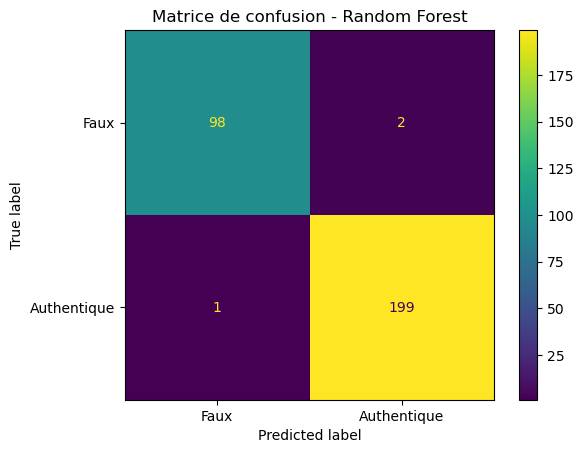

In [38]:
# Affichage de la matrice de confusion de la Random Forest.
#
# False = faux billet
# True  = billet authentique.
#
# Elle permettra notamment d'identifier combien de faux billets
# ont été classés à tort comme authentiques.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=[False, True],
    display_labels=["Faux", "Authentique"]
)

plt.title("Matrice de confusion - Random Forest")
plt.show()

In [39]:
# Comparaison des performances entre les données d'entraînement
# et les données de test.
#
# Cette comparaison permet notamment d'observer si la Random Forest
# apprend très fortement les données d'entraînement mais généralise
# moins bien sur de nouvelles observations.

accuracy_train_rf = pipeline_rf.score(
    X_train,
    y_train
)

accuracy_test_rf = pipeline_rf.score(
    X_test,
    y_test
)


print(
    "Accuracy train :",
    round(accuracy_train_rf, 3)
)

print(
    "Accuracy test :",
    round(accuracy_test_rf, 3)
)

Accuracy train : 1.0
Accuracy test : 0.99


### Conclusion - Random Forest

La Random Forest obtient une accuracy de 100 % sur l'ensemble d'entraînement et de 99 % sur l'ensemble de test. Malgré une performance parfaite sur les données d'entraînement, la performance reste très élevée sur les données non vues.

Sur l'ensemble de test, le modèle détecte correctement 98 % des faux billets. Deux faux billets sont classés à tort comme authentiques.

Les performances obtenues sont comparables à celles de la régression logistique sur le jeu de test. La sélection du modèle final sera donc réalisée après l'évaluation de l'ensemble des modèles demandés.

### 4.4 K-means

Contrairement aux modèles précédents, K-means est un algorithme d'apprentissage non supervisé. Il ne connaît donc pas la classe réelle des billets pendant la création des groupes.

L'objectif est ici de répartir les billets en deux clusters à partir de leurs caractéristiques géométriques. Deux clusters sont utilisés afin d'étudier si les groupes naturellement formés correspondent aux deux catégories de billets : faux et authentiques.

K-means reposant sur des distances aux centroïdes, les variables sont standardisées avant l'entraînement.

In [40]:
from sklearn.cluster import KMeans


# Création du pipeline de preprocessing pour K-means.
#
# K-means repose sur des distances :
# la standardisation est donc nécessaire.
pipeline_kmeans_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Apprentissage du preprocessing uniquement sur X_train,
# puis transformation des données d'entraînement.
X_train_kmeans = pipeline_kmeans_preprocessing.fit_transform(
    X_train
)


# Transformation de X_test avec les paramètres appris
# uniquement sur X_train.
X_test_kmeans = pipeline_kmeans_preprocessing.transform(
    X_test
)


# Création de K-means avec deux clusters.
#
# n_clusters=2 correspond aux deux groupes que nous souhaitons
# étudier : billets faux et billets authentiques.
#
# random_state permet de rendre l'initialisation reproductible.
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)


# IMPORTANT :
# K-means est non supervisé.
# Il est donc entraîné uniquement sur X_train et ne reçoit PAS y_train.
kmeans.fit(X_train_kmeans)


# Cluster attribué à chaque billet d'entraînement.
clusters_train = kmeans.labels_


# Affichage du nombre de billets dans chaque cluster.
np.unique(
    clusters_train,
    return_counts=True
)

(array([0, 1], dtype=int32), array([394, 806]))

In [41]:
# Création d'un tableau permettant de comparer
# les clusters obtenus avec les véritables classes du train.
#
# Cette étape intervient APRÈS l'entraînement de K-means :
# y_train n'a donc pas été utilisé pour créer les clusters.

analyse_clusters = pd.DataFrame({
    "cluster": clusters_train,
    "is_genuine": y_train.to_numpy()
})


# Tableau croisé entre les clusters et les véritables classes.
#
# Il permet d'identifier quelle classe est majoritaire
# dans chacun des deux clusters.
table_clusters = pd.crosstab(
    analyse_clusters["cluster"],
    analyse_clusters["is_genuine"]
)

table_clusters

is_genuine,False,True
cluster,,
0,388,6
1,12,794


In [42]:
# Association de chaque cluster à sa classe majoritaire.
#
# K-means attribue simplement les numéros 0 et 1 aux clusters :
# ces numéros n'ont aucune signification métier.
#
# Nous utilisons donc uniquement les données d'entraînement
# pour déterminer quelle classe réelle est majoritaire
# dans chacun des clusters.

cluster_to_class = {}


for cluster in table_clusters.index:

    # idxmax() retourne la classe ayant le plus grand nombre
    # d'observations dans le cluster considéré.
    classe_majoritaire = table_clusters.loc[cluster].idxmax()

    cluster_to_class[cluster] = classe_majoritaire


print("Correspondance cluster → classe :")
print(cluster_to_class)

Correspondance cluster → classe :
{0: np.False_, 1: np.True_}


In [43]:
# Attribution d'un cluster à chaque billet du jeu de test.
#
# predict() affecte chaque billet au centroïde
# dont il est le plus proche.
clusters_test = kmeans.predict(
    X_test_kmeans
)


# Conversion des numéros de clusters en classes métier
# grâce à la correspondance déterminée uniquement sur le train.
y_pred_kmeans = np.array([
    cluster_to_class[cluster]
    for cluster in clusters_test
])


# Affichage des dix premières prédictions.
y_pred_kmeans[:10]

array([ True, False, False,  True,  True,  True,  True,  True,  True,
        True])

In [44]:
# Calcul des performances générales de K-means
# après conversion des clusters en classes.

accuracy_kmeans = accuracy_score(
    y_test,
    y_pred_kmeans
)

precision_kmeans = precision_score(
    y_test,
    y_pred_kmeans
)

recall_kmeans = recall_score(
    y_test,
    y_pred_kmeans
)

f1_kmeans = f1_score(
    y_test,
    y_pred_kmeans
)


# Évaluation spécifique de la détection des faux billets.

recall_faux_kmeans = recall_score(
    y_test,
    y_pred_kmeans,
    pos_label=False
)

precision_faux_kmeans = precision_score(
    y_test,
    y_pred_kmeans,
    pos_label=False
)


print("Accuracy :", round(accuracy_kmeans, 3))
print("Precision :", round(precision_kmeans, 3))
print("Recall :", round(recall_kmeans, 3))
print("F1-score :", round(f1_kmeans, 3))

print(
    "Recall des faux billets :",
    round(recall_faux_kmeans, 3)
)

print(
    "Précision des faux billets :",
    round(precision_faux_kmeans, 3)
)

Accuracy : 0.987
Precision : 0.99
Recall : 0.99
F1-score : 0.99
Recall des faux billets : 0.98
Précision des faux billets : 0.98


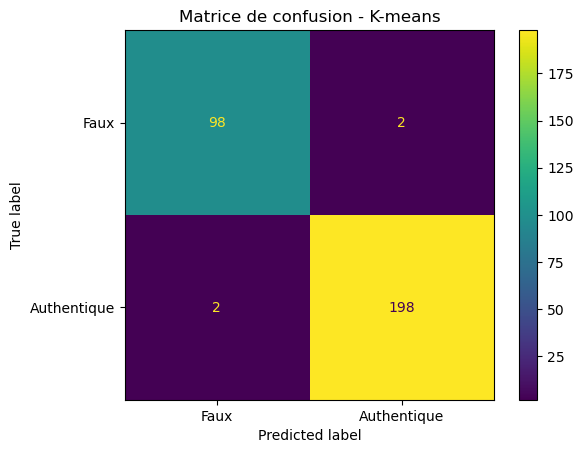

In [45]:
# Matrice de confusion de K-means.
#
# False = faux billet
# True  = billet authentique.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_kmeans,
    labels=[False, True],
    display_labels=["Faux", "Authentique"]
)

plt.title("Matrice de confusion - K-means")
plt.show()

### Conclusion - K-means

K-means obtient une accuracy de 98,7 % sur l'ensemble de test.

Bien que l'algorithme n'utilise pas la variable cible lors de la création des clusters, les deux groupes obtenus correspondent fortement aux deux catégories de billets. Sur l'ensemble d'entraînement, le cluster 0 contient majoritairement des faux billets tandis que le cluster 1 contient majoritairement des billets authentiques.

Après association de chaque cluster à sa classe majoritaire, le modèle détecte correctement 98 % des faux billets sur l'ensemble de test.

Ces résultats montrent que les caractéristiques géométriques permettent de distinguer naturellement les deux catégories. Cependant, K-means reste un algorithme non supervisé alors que la classe des billets est connue dans les données d'entraînement. Ses performances seront donc comparées à celles des modèles supervisés avant la sélection du modèle final.

## Sélection du meilleur modèle


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Affichage du rapport de classification de chaque modèle.
#
# labels=[False, True] permet de conserver explicitement :
# False = faux billet
# True  = billet authentique.
#
# Le classification_report présente notamment :
# - la précision ;
# - le recall (sensibilité) ;
# - le F1-score ;
# - le nombre d'observations de chaque classe (support).

predictions_modeles = {
    "Régression logistique": y_pred_log,
    "KNN": y_pred_knn,
}


for nom_modele, predictions in predictions_modeles.items():

    print(f"\n===== {nom_modele} =====")

    print(
        classification_report(
            y_test,
            predictions,
            labels=[False, True],
            target_names=["Faux", "Authentique"],
            digits=3
        )
    )


===== Régression logistique =====
              precision    recall  f1-score   support

        Faux      0.990     0.980     0.985       100
 Authentique      0.990     0.995     0.993       200

    accuracy                          0.990       300
   macro avg      0.990     0.988     0.989       300
weighted avg      0.990     0.990     0.990       300


===== KNN =====
              precision    recall  f1-score   support

        Faux      0.980     0.970     0.975       100
 Authentique      0.985     0.990     0.988       200

    accuracy                          0.983       300
   macro avg      0.982     0.980     0.981       300
weighted avg      0.983     0.983     0.983       300



In [47]:
# Affichage du rapport de classification de chaque modèle.(en 2 fois car trop long)
#
# labels=[False, True] permet de conserver explicitement :
# False = faux billet
# True  = billet authentique.
#
# Le classification_report présente notamment :
# - la précision ;
# - le recall (sensibilité) ;
# - le F1-score ;
# - le nombre d'observations de chaque classe (support).

predictions_modeles = {
    "Random Forest": y_pred_rf,
    "K-means": y_pred_kmeans
}


for nom_modele, predictions in predictions_modeles.items():

    print(f"\n===== {nom_modele} =====")

    print(
        classification_report(
            y_test,
            predictions,
            labels=[False, True],
            target_names=["Faux", "Authentique"],
            digits=3
        )
    )


===== Random Forest =====
              precision    recall  f1-score   support

        Faux      0.990     0.980     0.985       100
 Authentique      0.990     0.995     0.993       200

    accuracy                          0.990       300
   macro avg      0.990     0.988     0.989       300
weighted avg      0.990     0.990     0.990       300


===== K-means =====
              precision    recall  f1-score   support

        Faux      0.980     0.980     0.980       100
 Authentique      0.990     0.990     0.990       200

    accuracy                          0.987       300
   macro avg      0.985     0.985     0.985       300
weighted avg      0.987     0.987     0.987       300



In [48]:
# Construction d'un tableau récapitulatif permettant
# de comparer les quatre modèles avec les mêmes métriques.
#
# La classe métier prioritaire est celle des faux billets.
# Nous comparons donc notamment leur recall, leur précision
# et leur F1-score.

resultats_modeles = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "KNN",
        "Random Forest",
        "K-means"
    ],

    "Accuracy": [
        accuracy_log,
        accuracy_knn,
        accuracy_rf,
        accuracy_kmeans
    ],

    "Recall faux": [
        recall_faux_log,
        recall_faux_knn,
        recall_faux_rf,
        recall_faux_kmeans
    ],

    "Précision faux": [
        precision_faux_log,
        precision_faux_knn,
        precision_faux_rf,
        precision_faux_kmeans
    ],

    # Calcul du F1-score en considérant explicitement
    # les faux billets (False) comme classe d'intérêt.
    "F1-score (faux)": [
        f1_score(y_test, y_pred_log, pos_label=False),
        f1_score(y_test, y_pred_knn, pos_label=False),
        f1_score(y_test, y_pred_rf, pos_label=False),
        f1_score(y_test, y_pred_kmeans, pos_label=False)
    ]
})


# Arrondi uniquement pour faciliter la lecture.
resultats_modeles.round(3)

,Modèle,Accuracy,Recall faux,Précision faux,F1-score (faux)
0,Régression logistique,0.990,0.98,0.99,0.985
1,KNN,0.983,0.97,0.98,0.975
2,Random Forest,0.990,0.98,0.99,0.985
3,K-means,0.987,0.98,0.98,0.980


In [49]:
# Calcul de l'AUC pour les trois modèles supervisés.
#
# L'AUC mesure la capacité du modèle à distinguer les deux classes
# pour différents seuils de classification.
#
# Dans notre variable cible :
# False = faux billet
# True  = billet authentique.
#
# roc_auc_score considère ici True comme classe positive.
# On récupère donc la probabilité associée à la classe True
# (colonne d'indice 1 retournée par predict_proba).

# Régression logistique :
# le modèle ayant été entraîné précédemment sur les données
# standardisées, on utilise X_test_scaled.
proba_log = log_reg.predict_proba(
    X_test_scaled
)[:, 1]


# KNN :
# best_knn est déjà un pipeline contenant l'imputation
# et la standardisation. On lui fournit donc X_test brut.
proba_knn = best_knn.predict_proba(
    X_test
)[:, 1]


# Random Forest :
# pipeline_rf contient l'imputation nécessaire.
# On lui fournit également X_test brut.
proba_rf = pipeline_rf.predict_proba(
    X_test
)[:, 1]


# Calcul des AUC.
auc_log = roc_auc_score(
    y_test,
    proba_log
)

auc_knn = roc_auc_score(
    y_test,
    proba_knn
)

auc_rf = roc_auc_score(
    y_test,
    proba_rf
)


print(
    "AUC Régression logistique :",
    round(auc_log, 3)
)

print(
    "AUC KNN :",
    round(auc_knn, 3)
)

print(
    "AUC Random Forest :",
    round(auc_rf, 3)
)

AUC Régression logistique : 0.999
AUC KNN : 0.997
AUC Random Forest : 0.999


### Conclusion - Sélection du modèle final

Les quatre modèles présentent de très bonnes performances, mais la régression logistique et la Random Forest obtiennent les meilleurs résultats sur l'ensemble de test.

Ces deux modèles atteignent une accuracy de 99 %, un recall de 98 % pour les faux billets et une précision de 99 % pour cette même classe. Ils ne laissent ainsi passer que deux faux billets parmi les 100 présents dans l'ensemble de test. Leur AUC, proche de 1 (0,999), confirme également leur très forte capacité à distinguer les deux catégories de billets.

Le KNN obtient des performances légèrement inférieures, notamment avec un recall de 97 % pour les faux billets. K-means obtient également de très bons résultats, mais il s'agit d'un algorithme non supervisé alors que les classes des billets sont disponibles pour l'apprentissage.

La régression logistique est finalement retenue. Elle présente les mêmes performances que la Random Forest sur l'ensemble de test, tout en reposant sur un modèle plus simple. De plus, ses performances sont très proches entre l'entraînement (99,3 %) et le test (99,0 %), ce qui montre une bonne capacité de généralisation sur les données étudiées.

## Sauvegarde du meilleur modèle


In [50]:
from sklearn.pipeline import make_pipeline
import joblib


# Création du pipeline final.
#
# Les étapes sont exécutées dans l'ordre :
# 1. imputation des valeurs manquantes avec la médiane ;
# 2. standardisation des variables ;
# 3. classification par régression logistique.
#
# Grâce au pipeline, le même preprocessing sera automatiquement
# appliqué aux nouvelles données avant leur classification.

pipeline_final = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)


# Entraînement du pipeline sur les données d'entraînement brutes.
#
# On utilise X_train et non X_train_scaled :
# l'imputation et la standardisation sont réalisées
# directement par le pipeline.
pipeline_final.fit(
    X_train,
    y_train
)


# Évaluation du pipeline final sur le jeu de test brut.
print(
    "Accuracy du pipeline final :",
    round(pipeline_final.score(X_test, y_test), 3)
)

Accuracy du pipeline final : 0.99


In [51]:
# Sauvegarde du pipeline complet.
#
# Le fichier contient donc à la fois :
# - l'imputation ;
# - la standardisation ;
# - la régression logistique entraînée.

joblib.dump(
    pipeline_final,
    "modele_detection_billets.joblib"
)

print("Pipeline sauvegardé avec succès.")

Pipeline sauvegardé avec succès.


In [52]:
# Chargement du pipeline sauvegardé.
#
# Le modèle peut maintenant être utilisé sans réentraîner
# séparément l'imputer, le scaler ou la régression logistique.

modele_final = joblib.load(
    "modele_detection_billets.joblib"
)

In [53]:
# Chargement des billets à classifier.
#
# Ces billets ne possèdent pas de classe connue :
# le modèle doit déterminer s'ils sont authentiques ou faux.

billets_production = pd.read_csv(
    "billets_production.csv"
)

billets_production

,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


In [54]:
# Variables utilisées par le modèle.
#
# La colonne "id" sert uniquement à identifier les billets
# et ne doit jamais être utilisée pour la prédiction.

variables_modele = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length"
]


X_production = billets_production[
    variables_modele
]

X_production

,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.76,104.01,103.54,5.21,3.30,111.42
1,171.87,104.17,104.13,6.00,3.31,112.09
2,172.00,104.58,104.29,4.99,3.39,111.57
3,172.49,104.55,104.34,4.44,3.03,113.20
4,171.65,103.63,103.56,3.77,3.16,113.33


In [55]:
# Prédiction des billets de production.
#
# On fournit directement les données brutes :
# le pipeline réalise automatiquement l'imputation,
# la standardisation puis la classification.

predictions_production = modele_final.predict(
    X_production
)

predictions_production

array([False, False, False,  True,  True])

In [56]:
# Création du tableau final des prédictions.

resultats_production = billets_production.copy()


# Conservation de la prédiction booléenne :
# True = authentique
# False = faux.
resultats_production["is_genuine"] = (
    predictions_production
)


# Création d'un libellé lisible pour l'utilisateur.
resultats_production["prediction"] = np.where(
    predictions_production,
    "Authentique",
    "Faux"
)


# Résultat final.
resultats_production[
    ["id", "is_genuine", "prediction"]
]

,id,is_genuine,prediction
0,A_1,False,Faux
1,A_2,False,Faux
2,A_3,False,Faux
3,A_4,True,Authentique
4,A_5,True,Authentique
